# $E_L, E_T, \nu_L$ and $G_L$ reconstruction - (Fig 8, 9 and 10)

In [1]:
import dolfin as df
import math
import matplotlib.pyplot as plt
import numpy as np

from Transversly_isotropic_case_forward_pb import transversely_isotropic_elasticity_problem
from Transversly_isotropic_case_VFM import VFM

%load_ext autoreload
%autoreload 2

## $E_L, E_T, \nu_L$ and $G_L$ in terms of $C_{11}, C_{12}, C_{22}$ and $C_{33}$

In [2]:
def a_function(E_L, E_T, nu_L):
    return E_L*E_T/(E_L - E_T*nu_L**2)
def b_function(E_L, E_T, nu_L):
    return E_L*E_T*nu_L/(E_L - E_T*nu_L**2)
def c_function(E_L, E_T, nu_L):
    return E_L**2/(E_L - E_T*nu_L**2)
def d_function(G_L):
    return 2*G_L

def E_L_function(a,b,c):
    return  (a*c - b**2)/a 
def E_T_function(a,b,c):
    return (c*a - b**2 )/c
def nu_L_function(a,b):
    return b/a
def G_L_function(d):
    return d/2

## True parameters

In [ ]:
E_L, E_T, nu_L,G_L = 10.5, 6.5,0.45, 2.5  
coef_a= a_function(E_L, E_T, nu_L)
coef_b = b_function(E_L, E_T, nu_L)
coef_c = c_function(E_L, E_T, nu_L)
coef_d= d_function(G_L)
print(coef_a, coef_b, coef_c, coef_d)

7.431604736627195 3.344222131482238 12.004899959167007 5.0


## Parameters

In [4]:
degree = 3
dim = 2
Nx = 50
Ny = 50
u_boundary = df.Constant((0,0))  
T=  df.Expression(('1', '-1'), degree=1)
f = df.Constant((0,0))

tol = 1e-15

alpha1=1e16
alpha2=1e32
alpha3=1e32

mat_params = {"coef_a":coef_a, "coef_b":coef_b, "coef_c":coef_c, "coef_d":coef_d}
mesh_params = {"Nx":Nx, "Ny":Ny, "degree":degree}
load_params = {"u_boundary":u_boundary, "f":f ,"T":T}


## Direct problem

In [5]:
ureal, ureal_norm = transversely_isotropic_elasticity_problem(
        mesh_params,
        mat_params,
        load_params)

print(ureal_norm)

Solving linear variational problem.
0.6014345183878155


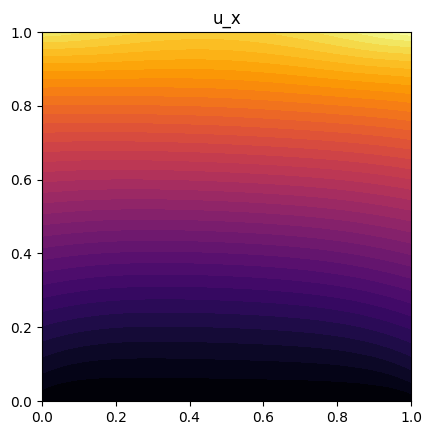

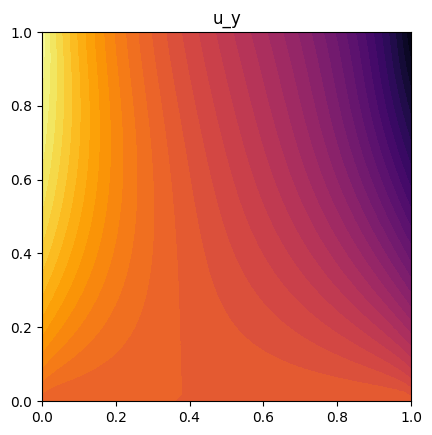

In [6]:
u1, u2 = ureal.split()
df.plot(u1, title="u_x", cmap="inferno")
plt.show()

df.plot(u2, title="u_y", cmap="inferno")
plt.show()

## Reconstruction- Noiseless data

In [7]:
V1 = ureal.function_space()
A_VFM,B_VFM,X = VFM(ureal, V1,  alpha1, alpha2, alpha3, T)

Solving linear variational problem.
Solving linear variational problem.
Global values of m : [-4.09861982e-17 -1.76877014e-33 -4.19508248e-34]
Solving linear variational problem.
Solving linear variational problem.
Global values of m : [-2.15679120e-08 -4.30218889e-17 -9.95437993e-18]
Solving linear variational problem.
Solving linear variational problem.
Global values of m : [-8.58841869e-09 -1.85808509e-16 -3.39191416e-17]
Solving linear variational problem.
Solving linear variational problem.
Global values of m : [-3.58540903e-09 -7.95125109e-17 -6.11991817e-17]
X= [ 7.43160474  3.34422213 12.00489996  5.        ]


In [8]:
print("A_VFM = ", A_VFM)
print("B_VFM = ", B_VFM)

A_VFM =  [[ 2.75684638e-02 -1.08321741e-14 -2.35847176e-15  5.00411480e-15]
 [-3.77998278e-15  6.32408648e-02 -2.83714024e-15  5.75823670e-15]
 [-1.19506184e-15 -4.22258935e-14  8.93531087e-02 -3.23126806e-15]
 [ 2.69775335e-15 -3.51230724e-14  1.15133080e-15  2.40043551e-01]]
B_VFM =  [0.20487793 0.2114915  1.07267513 1.20021776]


In [9]:
Err_EL_list = []
Err_ET_list = []
Err_GL_list = []
Err_nuL_list = []
Err_Coefa_list= []
Err_coefb_list= []
Err_coefc_list= []
Err_coefd_list= []
SNR_list = [0]

Err_Coefa_list.append(abs(X[0]-coef_a)*100/coef_a)
Err_coefb_list.append(abs(X[1]-coef_b)*100/coef_b)
Err_coefc_list.append(abs(X[2]-coef_c)*100/coef_c)
Err_coefd_list.append(abs(X[3]-coef_d)*100/coef_d)

E_L_rec= E_L_function(X[0],X[1],X[2]) 
print("E_L_rec = ", E_L_rec)
Err_EL= abs(E_L_rec-E_L)/E_L
print ("Relative error for E_L", Err_EL)
Err_EL_list.append(Err_EL*100)

E_T_rec= E_T_function(X[0],X[1],X[2]) 
print("E_T_rec=" ,E_T_rec)
Err_ET = abs(E_T_rec-E_T)/E_T
print("Relative error for E_T", Err_ET)
Err_ET_list.append(Err_ET*100)

G_L_rec= G_L_function(X[3]) 
print("G_L_rec =", G_L_rec)
Err_GL = abs(G_L_rec-G_L)/G_L
print("Relative error for G_L", Err_GL)
Err_GL_list.append(Err_GL*100)

nu_L_rec= nu_L_function(X[0],X[1])
print("nu_L_rec=", nu_L_rec)
Err_nuL = abs(nu_L_rec-nu_L)/nu_L
print("Relative error for nu_L", Err_nuL)
Err_nuL_list.append(Err_nuL*100)
 

E_L_rec =  10.50000000158742
Relative error for E_L 1.511828545950439e-10
E_T_rec= 6.500000001160799
Relative error for E_T 1.7858439513509858e-10
G_L_rec = 2.500000000365549
Relative error for G_L 1.4621956978544404e-10
nu_L_rec= 0.4499999999963799
Relative error for nu_L 8.044676036433884e-12


## Reconstruction - Noisy data

### Noisy data

In [10]:
Noise_list=np.array( [ 0.01,  0.05,0.08,  0.1, 0.15, 0.17,  0.2,0.23, 0.26 ])  # Example (a)
#Noise_list=np.array( [ 0.01,  0.05,0.08, 0.10, 0.13, 0.15, 0.17 ])  # Example(b)

 
size_noise=np.size(Noise_list)
V1 = ureal.function_space()
mesh= V1.mesh()
dx = df.Measure("dx", domain=mesh)

def epsilon(u):
   return 0.5*(df.nabla_grad(u) + df.nabla_grad(u).T) 

for k in range(size_noise) :   
    print("Noise = ", Noise_list[k])
    
    class noiseExpression(df.UserExpression):
        def eval(self, value, x):
           value[0]=Noise_list[k]* (x[0]**2+ x[1]**2)
           value[1]=Noise_list[k]* (x[0]**2+ x[1]**2)
        def value_shape(self):
           return (2,)

    noise_Expression= noiseExpression()
    noise_Expression= df.interpolate(noise_Expression, V1)  
    u_noised= df.Function(V1)   
    u_noised.vector()[:] = ureal.vector()[:] *(1+ noise_Expression.vector()[:])  

    SNR = math.sqrt(df.assemble((epsilon(ureal) - epsilon(u_noised))**2 * dx ) + df.assemble((ureal - u_noised)**2 * dx) )/ ureal_norm
    SNR_list.append(SNR*100)
    print("SNR", SNR)

    A_VFM,B_VFM,X = VFM(u_noised, V1,  alpha1, alpha2, alpha3, T)
    print(A_VFM,B_VFM)
    Err_Coefa_list.append(abs(X[0]-coef_a)*100/coef_a)
    Err_coefb_list.append(abs(X[1]-coef_b)*100/coef_b)
    Err_coefc_list.append(abs(X[2]-coef_c)*100/coef_c)
    Err_coefd_list.append(abs(X[3]-coef_d)*100/coef_d)
    
    E_L_rec= E_L_function(X[0],X[1],X[2]) 
    print("E_L_rec = ", E_L_rec)
    Err_EL= abs(E_L_rec-E_L)/E_L
    print ("Relative error for E_L", Err_EL)
    Err_EL_list.append(Err_EL*100)

    E_T_rec= E_T_function(X[0],X[1],X[2]) 
    print("E_T_rec=" ,E_T_rec)
    Err_ET = abs(E_T_rec-E_T)/E_T
    print("Relative error for E_T", Err_ET)
    Err_ET_list.append(Err_ET*100)

    G_L_rec= G_L_function(X[3]) 
    print("G_L_rec =", G_L_rec)
    Err_GL = abs(G_L_rec-G_L)/G_L
    print("Relative error for G_L", Err_GL)
    Err_GL_list.append(Err_GL*100)

    nu_L_rec= nu_L_function(X[0],X[1])
    print("nu_L_rec=", nu_L_rec)
    Err_nuL = abs(nu_L_rec-nu_L)/nu_L
    print("Relative error for nu_L", Err_nuL)
    Err_nuL_list.append(Err_nuL*100)

Noise =  0.01
SNR 0.01762959245413584
Solving linear variational problem.
Solving linear variational problem.
Global values of m : [-4.23616010e-17 -1.96085710e-33 -4.77470051e-34]
Solving linear variational problem.
Solving linear variational problem.
Global values of m : [-2.07526147e-08 -4.61386687e-17 -1.09548884e-17]
Solving linear variational problem.
Solving linear variational problem.
Global values of m : [-8.51955687e-09 -1.77377427e-16 -3.35660818e-17]
Solving linear variational problem.
Solving linear variational problem.
Global values of m : [-3.79001391e-09 -8.09243911e-17 -6.28899932e-17]
X= [ 7.00655759  3.26808558 11.9058883   4.91352869]
[[ 2.96091449e-02 -8.86228380e-15 -2.62376248e-15  5.03458596e-15]
 [ 1.48831143e-15  6.55354210e-02 -2.62571405e-15  2.60298815e-15]
 [ 2.83070279e-15 -4.18710172e-14  8.90537204e-02  5.99615979e-15]
 [ 4.90827006e-15 -2.81847384e-14  1.51757049e-15  2.43793719e-01]] [0.20745818 0.21417536 1.06026365 1.19788743]
E_L_rec =  10.38154724

SNR_list= [0, 1.762959245413584, 8.81479622706782, 14.103673963308522, 17.62959245413567, 26.444388681203456, 29.97030717203058, 35.259184908271266, 40.54806264451196, 45.83694038075269]


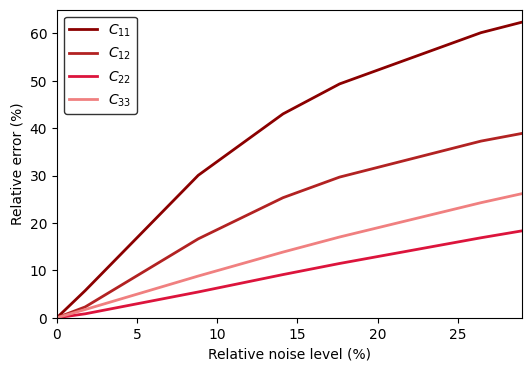

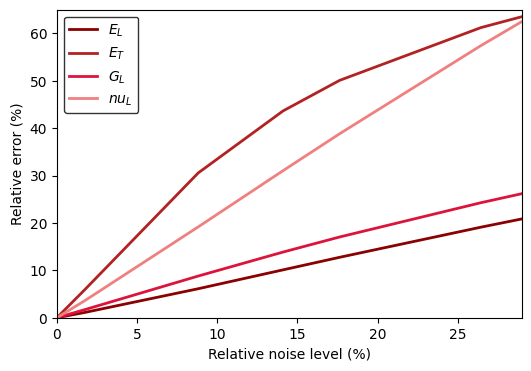

In [11]:
print("SNR_list=", SNR_list)
fig, ax = plt.subplots(figsize=(6, 4))   

ax.plot(SNR_list, Err_Coefa_list,  color="darkred", label="$C_{11}$", linewidth=2)
ax.plot(SNR_list, Err_coefb_list, color="firebrick",  label="$C_{12}$", linewidth=2)
ax.plot(SNR_list, Err_coefc_list, color="crimson", label="$C_{22}$", linewidth=2)
ax.plot(SNR_list, Err_coefd_list, "-", color="lightcoral",label="$C_{33}$", linewidth=2)

ax.set_xlabel('Relative noise level (%)')
ax.set_ylabel('Relative error (%)')

ax.legend(frameon=True, edgecolor="black", facecolor="white", fontsize=10,
           title_fontsize=10)
ax.set_ylim(0, 65)   
ax.set_xlim(0, 29)  

plt.show()


fig, ax = plt.subplots(figsize=(6, 4))   

ax.plot(SNR_list, Err_EL_list,  color="darkred",  label="$E_L$", linewidth=2)
ax.plot(SNR_list, Err_ET_list, color="firebrick", label="$E_T$", linewidth=2)
ax.plot(SNR_list, Err_GL_list, color="crimson",label="$G_L$", linewidth=2)
ax.plot(SNR_list, Err_nuL_list, "-",color="lightcoral", label="${nu} _L$", linewidth=2)

ax.set_xlabel('Relative noise level (%)')
ax.set_ylabel('Relative error (%)')
 
ax.legend(frameon=True, edgecolor="black", facecolor="white", fontsize=10,
      title_fontsize=10)
ax.set_ylim(0, 65)   
ax.set_xlim(0, 29)  

plt.show()

